In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Параметры среды
depth = 1000
velocity = 2500
dominant_freq = 30
dt = 0.001
time_window = 1.2
R = 0.3

In [3]:
# 2. Время прихода
t0 = 2 * depth / velocity
print(f"t0 = {t0:.4f} с")

t0 = 0.8000 с


In [4]:
# 3. Временная сетка
time = np.arange(0, time_window, dt)
num_samples = len(time)

In [5]:
# 4. Вейвлет Рикера
def ricker_wavelet(t, f_p):
    tau = np.pi * f_p * t
    return (1 - 2 * tau**2) * np.exp(-tau**2)

In [6]:
# 5. Генерация трассы
wavelet_at_t0 = ricker_wavelet(time - t0, dominant_freq)
trace = R * wavelet_at_t0

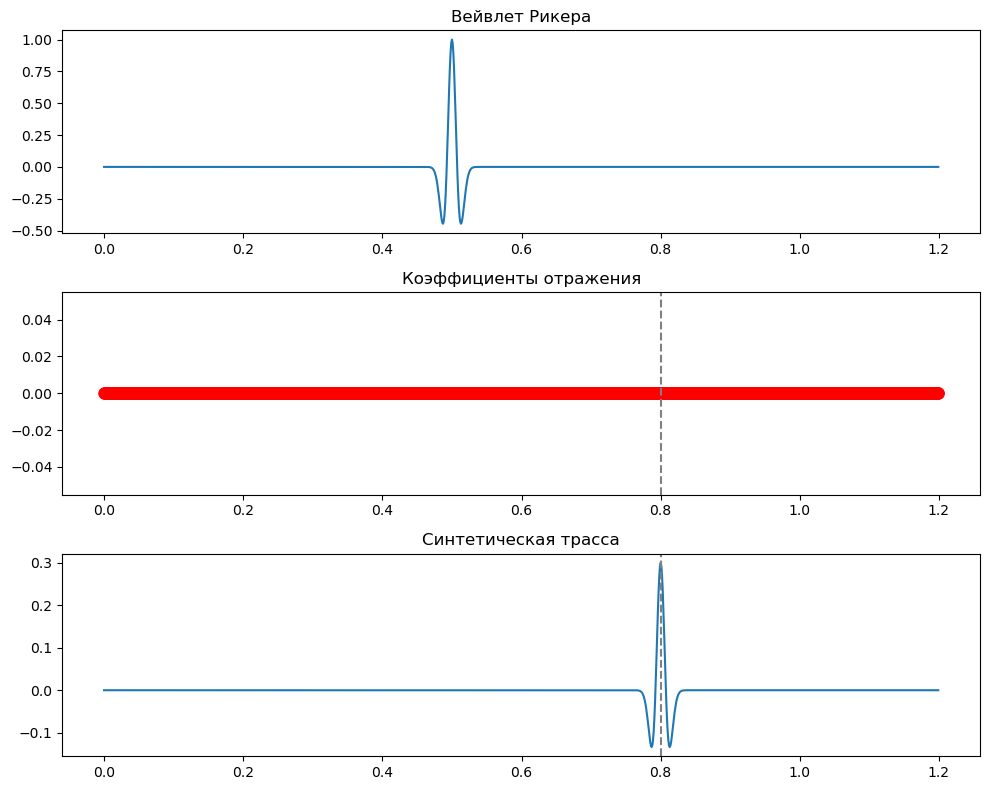

In [7]:
# 6. Визуализация
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].plot(time, ricker_wavelet(time - 0.5, dominant_freq))
axes[0].set_title('Вейвлет Рикера')

axes[1].plot(time, np.zeros(num_samples), 'ro', markersize=8)
axes[1].axvline(x=t0, color='gray', linestyle='--')
axes[1].set_title('Коэффициенты отражения')

axes[2].plot(time, trace)
axes[2].axvline(x=t0, color='gray', linestyle='--')
axes[2].set_title('Синтетическая трасса')

plt.tight_layout()
plt.show()